In [1]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

import scipy.sparse.linalg as sla

import modules.tools as tools
import modules.models as models

%matplotlib inline

In [2]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [3]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

In [4]:
from numpy import cos, sin, pi, exp, sqrt

In [5]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [106]:
import os
import pickle

## Magnetic order

### Different order parameters

In [88]:
Nx = 91

R = 800
t1 = 0.25
t2 = 0.8
Lz = 200
B = 0.025

ky = 0.0
kxs = np.linspace(-0.8,0.8,Nx)

#### (i) zero field

In [92]:
evals0 = np.zeros((Nx,4*Lz))
evecs0 = np.zeros((Nx,4*Lz,4*Lz), dtype='complex')

for i,kx in tqdm(list(enumerate(kxs))):
    evals0[i,:], evecs0[i,:,:] = np.linalg.eigh(models.H_strain_ferro(kx, ky, Lz, R, t1, t2, B=0.0))

(-0.8, 0.8)

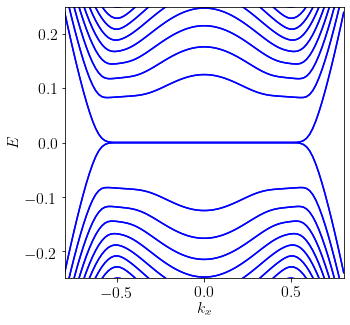

In [93]:
plt.figure(figsize=(5,5))
plt.plot(kxs,evals0,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)

#### (i) sigma_0

In [94]:
evals1 = np.zeros((Nx,4*Lz))
evecs1 = np.zeros((Nx,4*Lz,4*Lz), dtype='complex')

order = np.kron(sz,s0)

for i,kx in tqdm(list(enumerate(kxs))):
    evals1[i,:], evecs1[i,:,:] = np.linalg.eigh(models.H_strain_ferro(kx, ky, Lz, R, t1, t2, B, order))

(-0.8, 0.8)

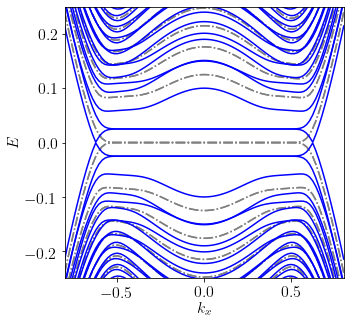

In [96]:
plt.figure(figsize=(5,5))
plt.plot(kxs,evals0,c='gray', ls='-.')
plt.plot(kxs,evals1,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)

#### (ii) sigma_x

In [97]:
evals2 = np.zeros((Nx,4*Lz))
evecs2 = np.zeros((Nx,4*Lz,4*Lz), dtype='complex')

order = np.kron(sz,sx)

for i,kx in tqdm(list(enumerate(kxs))):
    evals2[i,:], evecs2[i,:,:] = np.linalg.eigh(models.H_strain_ferro(kx, ky, Lz, R, t1, t2, B, order))

(-0.8, 0.8)

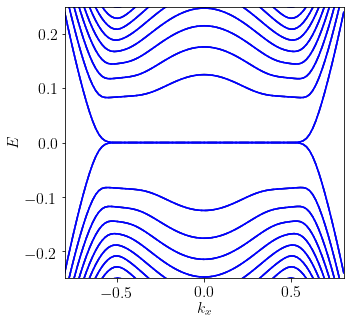

In [99]:
plt.figure(figsize=(5,5))
plt.plot(kxs,evals0,c='gray', ls='-.')
plt.plot(kxs,evals2,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)

#### (iii) sigma_y

In [100]:
evals3 = np.zeros((Nx,4*Lz))
evecs3 = np.zeros((Nx,4*Lz,4*Lz), dtype='complex')

order = np.kron(sz,sy)

for i,kx in tqdm(list(enumerate(kxs))):
    evals3[i,:], evecs3[i,:,:] = np.linalg.eigh(models.H_strain_ferro(kx, ky, Lz, R, t1, t2, B, order))

(-0.8, 0.8)

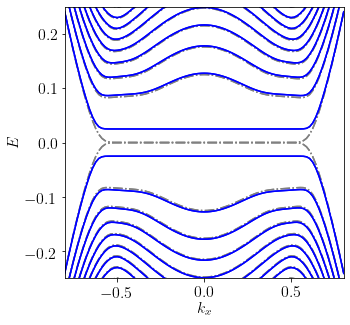

In [101]:
plt.figure(figsize=(5,5))
plt.plot(kxs,evals0,c='gray', ls='-.')
plt.plot(kxs,evals3,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)

#### (iv) sigma_z

In [102]:
evals4 = np.zeros((Nx,4*Lz))
evecs4 = np.zeros((Nx,4*Lz,4*Lz), dtype='complex')

order = np.kron(sz,sz)

for i,kx in tqdm(list(enumerate(kxs))):
    evals4[i,:], evecs4[i,:,:] = np.linalg.eigh(models.H_strain_ferro(kx, ky, Lz, R, t1, t2, B, order))

(-0.8, 0.8)

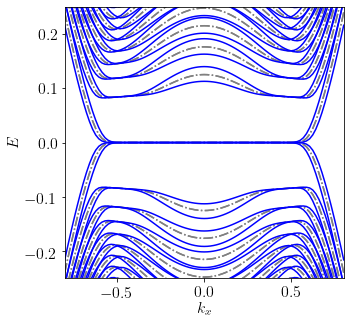

In [103]:
plt.figure(figsize=(5,5))
plt.plot(kxs,evals0,c='gray', ls='-.')
plt.plot(kxs,evals4,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.25,0.25)
plt.xlim(-0.8,0.8)

Only the sigma_y term leads to a fully gapped spectrum!

#### Save to file for figures

In [104]:
params_save = dict(t1=t1, t2=t2, R=R, Lz=Lz, Nx=Nx, B=B)

In [107]:
# Write everything to a pickle file
path = os.path.dirname(os.getcwd()) + '/data/'
out_name = 'magnetic_orders_spectra'
fp = open(path + out_name + '.p', 'wb')
pickle.dump(params_save, fp)
pickle.dump(kxs, fp)
pickle.dump(evals0, fp)
pickle.dump(evals1, fp)
pickle.dump(evals2, fp)
pickle.dump(evals3, fp)
pickle.dump(evals4, fp)
fp.close()

### Negligible strain

In [6]:
Nx = 51

R = 100000
t1 = 1.0
t2 = 1.0
Lz = 100
B = 0.1

ky = 0.0
kxs = np.linspace(-1.5,1.5,Nx)

evals = np.zeros((Nx,4*Lz))
evecs = np.zeros((Nx,4*Lz,4*Lz), dtype='complex')

for i,kx in tqdm(list(enumerate(kxs))):
    evals[i,:], evecs[i,:,:] = np.linalg.eigh(models.H_strain_ferro(kx, ky, Lz, R, t1, t2, B))

(-1.5, 1.5)

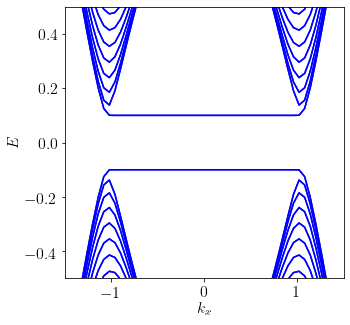

In [7]:
plt.figure(figsize=(5,5))
plt.plot(kxs,evals,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.5,0.5)
plt.xlim(-1.5,1.5)

In [8]:
n=25
print(evals[n,2*Lz-2:2*Lz+2])

[-0.1 -0.1  0.1  0.1]


In [9]:
evecs_1 = evecs[n,:,2*Lz-2]
evecs_2 = evecs[n,:,2*Lz-1]
evecs_3 = evecs[n,:,2*Lz]
evecs_4 = evecs[n,:,2*Lz+1]

In [10]:
densities_1 = tools.density(evecs_1, 4)
densities_2 = tools.density(evecs_2, 4)
densities_3 = tools.density(evecs_3, 4)
densities_4 = tools.density(evecs_4, 4)

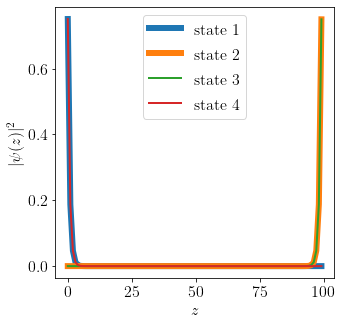

In [11]:
plt.figure(figsize=(5,5))
plt.plot(densities_1, label='state 1', lw=6)
plt.plot(densities_2, label='state 2', lw=6)
plt.plot(densities_3, label='state 3', lw=2)
plt.plot(densities_4, label='state 4', lw=2)
plt.xlabel('$z$')
plt.ylabel('$|\psi(z)|^2$')
plt.legend()

#### Sizable strain

Ensure that $L_z/2 < R$.

In [12]:
Nx = 51

R = 100
t1 = 1.0
t2 = 1.0
Lz = 100
B = 0.1

ky = 0.0
kxs = np.linspace(-1.5,1.5,Nx)

evals = np.zeros((Nx,4*Lz))
evecs = np.zeros((Nx,4*Lz,4*Lz), dtype='complex')

for i,kx in tqdm(list(enumerate(kxs))):
    evals[i,:], evecs[i,:,:] = np.linalg.eigh(models.H_strain_ferro(kx, ky, Lz, R, t1, t2, B))

(-1.5, 1.5)

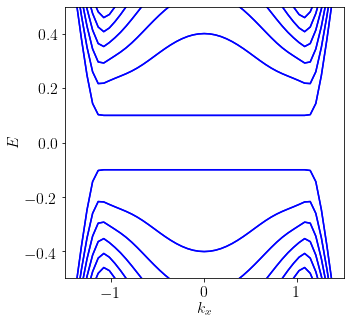

In [13]:
plt.figure(figsize=(5,5))
plt.plot(kxs,evals,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-0.5,0.5)
plt.xlim(-1.5,1.5)

In [14]:
n=25
print(evals[n,2*Lz-2:2*Lz+2])

[-0.1 -0.1  0.1  0.1]


In [15]:
evecs_1 = evecs[n,:,2*Lz-2]
evecs_2 = evecs[n,:,2*Lz-1]
evecs_3 = evecs[n,:,2*Lz]
evecs_4 = evecs[n,:,2*Lz+1]

In [16]:
densities_1 = tools.density(evecs_1, 4)
densities_2 = tools.density(evecs_2, 4)
densities_3 = tools.density(evecs_3, 4)
densities_4 = tools.density(evecs_4, 4)

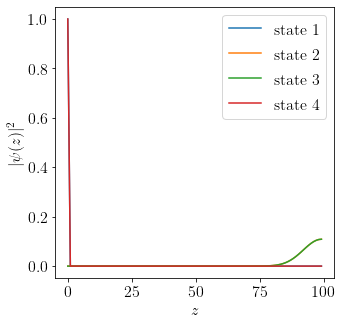

In [17]:
plt.figure(figsize=(5,5))
plt.plot(densities_1, label='state 1')
plt.plot(densities_2, label='state 2')
plt.plot(densities_3, label='state 3')
plt.plot(densities_4, label='state 4')
plt.xlabel('$z$')
plt.ylabel('$|\psi(z)|^2$')
plt.legend()

In [18]:
def spin_z_density(evec):
    N = len(evec)//4
    spin_density = np.zeros(N)
    sz_operator = np.kron(sz,s0)
    for i in range(N):
        sz_local = np.zeros((4*N,4*N))
        sz_local[4*i:4*(i+1),4*i:4*(i+1)] = sz_operator
        spin_density[i] = np.real(np.transpose(np.conjugate(evec)) @ sz_local @ evec)
    return spin_density

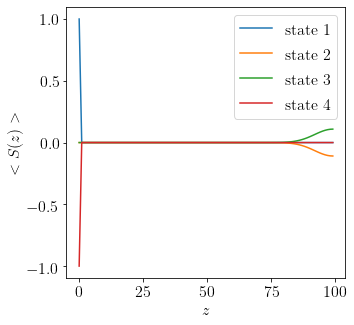

In [19]:
plt.figure(figsize=(5,5))
plt.plot(spin_z_density(evecs_1), label='state 1')
plt.plot(spin_z_density(evecs_2), label='state 2')
plt.plot(spin_z_density(evecs_3), label='state 3')
plt.plot(spin_z_density(evecs_4), label='state 4')
plt.xlabel('$z$')
plt.ylabel('$<S(z)>$')
plt.legend()